In [ ]:
import torch
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
else:
    print("❌ PAS DE GPU ! Il faut changer le type d'exécution.")

CUDA disponible : False
❌ PAS DE GPU ! Il faut changer le type d'exécution.


In [ ]:
  import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt

print("Librairies chargées avec succès !")

Librairies chargées avec succès !


In [ ]:
import pandas as pd
import requests
import io

print("Connexion au serveur... (Contournement de la sécurité anti-bot)")

url_isic = "https://dataverse.harvard.edu/api/access/datafile/3172582"

# 1. On crée une fausse "carte d'identité" de navigateur web (Chrome sur Windows 10)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

# 2. On envoie la requête avec cette carte d'identité
response = requests.get(url_isic, headers=headers)

if response.status_code == 200:
    # 3. Le serveur a accepté ! On lit le texte reçu et on le transforme en dataframe
# On ajoute sep='\t' pour lui dire que les colonnes sont séparées par des tabulations
    df_isic = pd.read_csv(io.StringIO(response.text), sep='\t')
    # Renommer 'lesion_id' en 'patient_id' pour notre logique de split
    df = df_isic.rename(columns={'lesion_id': 'patient_id', 'dx': 'diagnosis'})

    print(f"✅ Succès ! Le serveur a été trompé. Nombre d'images chargées : {len(df)}")
    display(df.head())
else:
    print(f"❌ Échec. Le serveur a répondu avec le code : {response.status_code}")
    print("Solution alternative : Tu devras télécharger le fichier HAM10000_metadata.csv manuellement sur ISIC/Kaggle et le glisser dans tes fichiers Colab.")

Connexion au serveur... (Contournement de la sécurité anti-bot)
✅ Succès ! Le serveur a été trompé. Nombre d'images chargées : 10015


,patient_id,image_id,diagnosis,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
# Dans ISIC HAM10000, les diagnostics graves/cancers sont :
# 'mel' (Mélanome), 'bcc' (Carcinome basocellulaire), 'akiec' (Kératose actinique)
malignant_classes = ['mel', 'bcc', 'akiec']

# Création de notre colonne cible (0 = Bénin, 1 = Malin)
df['target'] = df['diagnosis'].apply(lambda x: 1 if x in malignant_classes else 0)

print("\nRépartition exacte des maladies dans ce dataset ISIC :")
print(df['diagnosis'].value_counts())

print("\nRépartition Bénin (0) / Cancer (1) :")
print(df['target'].value_counts())


Répartition exacte des maladies dans ce dataset ISIC :
diagnosis
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Répartition Bénin (0) / Cancer (1) :
target
0    8061
1    1954
Name: count, dtype: int64


In [ ]:
# 1. Remplacer l'âge manquant par la médiane des âges
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

# 2. Remplacer le sexe manquant par une catégorie 'unknown'
df['sex'] = df['sex'].fillna('unknown')

# 3. Remplacer la localisation manquante par 'unknown'
df['localization'] = df['localization'].fillna('unknown')

# 4. Encodage : Transformer le texte en nombres (One-Hot Encoding)
# Les modèles n'aiment pas le texte. 'male' devient des colonnes 0 et 1.
df_clean = pd.get_dummies(df, columns=['sex', 'localization'])

print("=== APERÇU APRÈS NETTOYAGE ET ENCODAGE ===")
display(df_clean)

=== APERÇU APRÈS NETTOYAGE ET ENCODAGE ===


,patient_id,image_id,diagnosis,dx_type,age,target,sex_female,sex_male,sex_unknown,localization_abdomen,...,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,1,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,1,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,1,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,1,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
# Séparation 80% Train / 20% (Validation + Test)
# Le paramètre 'groups' est la clé : il force les patient_id à rester groupés.
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss.split(df_clean, groups=df_clean['patient_id']))

train_df = df_clean.iloc[train_idx].copy()
temp_df = df_clean.iloc[temp_idx].copy()

# Séparation des 20% restants en : 10% Validation / 10% Test
gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(temp_df, groups=temp_df['patient_id']))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print(f"Taille du set d'Entraînement : {len(train_df)} images")
print(f"Taille du set de Validation  : {len(val_df)} images")
print(f"Taille du set de Test        : {len(test_df)} images")

Taille du set d'Entraînement : 7991 images
Taille du set de Validation  : 1025 images
Taille du set de Test        : 999 images


In [ ]:
# On extrait la liste des patients uniques dans chaque set
train_patients = set(train_df['patient_id'])
val_patients = set(val_df['patient_id'])
test_patients = set(test_df['patient_id'])

# On vérifie s'il y a des patients en commun (intersection)
leak_val = train_patients.intersection(val_patients)
leak_test = train_patients.intersection(test_patients)

print("=== VÉRIFICATION DES FUITES DE DONNÉES (DATA LEAKAGE) ===")
if len(leak_val) == 0 and len(leak_test) == 0:
    print("✅ PARFAIT ! Aucun patient n'est mélangé entre l'entraînement et les tests.")
else:
    print("❌ ALERTE ! Problème de fuite :")
    print(f"- Patients en commun Train/Val : {leak_val}")
    print(f"- Patients en commun Train/Test : {leak_test}")

print("\nRépartition des cancers (Target=1) dans le Train :")
print(train_df['target'].value_counts())

=== VÉRIFICATION DES FUITES DE DONNÉES (DATA LEAKAGE) ===
✅ PARFAIT ! Aucun patient n'est mélangé entre l'entraînement et les tests.

Répartition des cancers (Target=1) dans le Train :
target
0    6430
1    1561
Name: count, dtype: int64


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV chargé avec succès !")

OpenCV chargé avec succès !


In [ ]:
import cv2
import numpy as np

def remove_hair_dullrazor_smart(image_path):
    # 1. Chargement
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"❌ Impossible de lire {image_path}.")

    # --- LA RÈGLE D'OR : LE RESIZING ---
    # On force toutes les images (4K, zooms, petites photos) à faire 512x512 pixels.
    # Ainsi, l'épaisseur des poils sera toujours standardisée pour nos filtres !
    img = cv2.resize(img, (512, 512))

    # 2. Couleurs
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    grayScale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # 3. Scanners (Le 17x17 marchera toujours grâce au resize !)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    tophat = cv2.morphologyEx(grayScale, cv2.MORPH_TOPHAT, kernel)

    # 4. Création du Masque
    mask_combined = np.where((blackhat > 40) | (tophat > 50), 255, 0).astype(np.uint8)
    mask_combined = cv2.medianBlur(mask_combined, 3)

    # 5. Dilatation
    kernel_dilatation = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask_combined = cv2.dilate(mask_combined, kernel_dilatation, iterations=1)

    # 6. Inpainting
    img_inpainted = cv2.inpaint(img, mask_combined, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

    return img, mask_combined, img_inpainted

print("✅ Cellule 2 : Version de Production (Avec Resizing) prête !")

✅ Cellule 2 : Version de Production (Avec Resizing) prête !


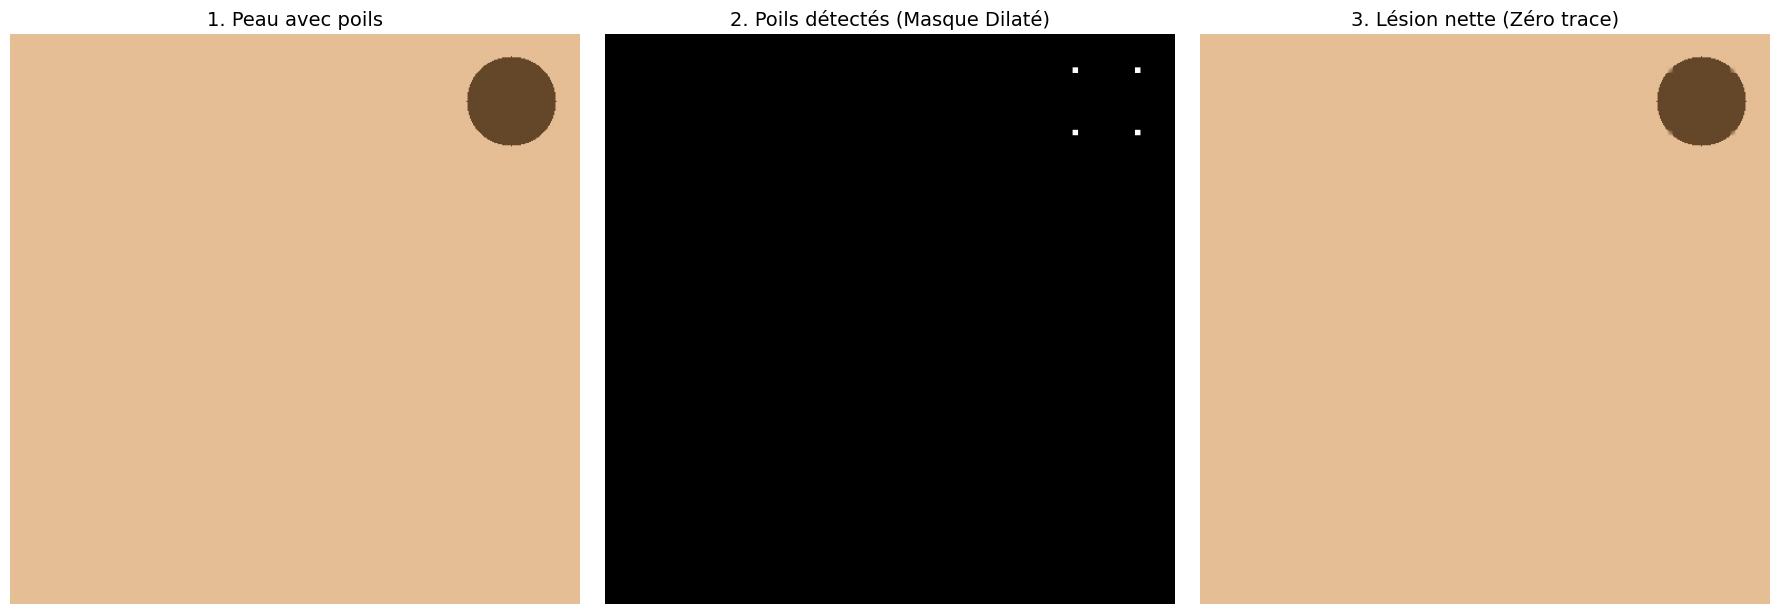

In [ ]:
import matplotlib.pyplot as plt

# C'est cette ligne qui "démarre le moteur" de la cellule précédente !
original, mask, cleaned_image = remove_hair_dullrazor_smart('test_excentre.jpg')

# --- Code pour afficher les images sur l'écran ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original)
axes[0].set_title("1. Peau avec poils", fontsize=14)
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("2. Poils détectés (Masque Dilaté)", fontsize=14)
axes[1].axis('off')

axes[2].imshow(cleaned_image)
axes[2].set_title("3. Lésion nette (Zéro trace)", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Installation du modèle SAM de Meta et téléchargement de son "cerveau"
!pip install git+https://github.com/facebookresearch/segment-anything.git
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

print("✅ SAM installé avec succès !")

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-5te4p8qj
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-5te4p8qj
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
✅ SAM installé avec succès !


In [ ]:
import cv2
import torch
import numpy as np
from segment_anything import sam_model_registry, SamPredictor

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device=DEVICE)
predictor = SamPredictor(sam)

def segment_lesion_hybride(cleaned_image):
    # --- TON IDÉE N°1 : L'ANOMALIE DE COULEUR ---
    lab_img = cv2.cvtColor(cleaned_image, cv2.COLOR_RGB2LAB).astype(np.float32)

    # Correction : On calcule la moyenne de chaque bord de peau séparément
    haut = np.mean(lab_img[0:10, :], axis=(0, 1))
    bas = np.mean(lab_img[-10:, :], axis=(0, 1))
    gauche = np.mean(lab_img[:, 0:10], axis=(0, 1))
    droite = np.mean(lab_img[:, -10:], axis=(0, 1))

    # Moyenne globale de la peau du patient
    peau_normale = np.mean([haut, bas, gauche, droite], axis=0)

    difference = lab_img - peau_normale
    carte_anomalie = np.sqrt(np.sum(difference**2, axis=2))
    carte_anomalie_lisse = cv2.GaussianBlur(carte_anomalie, (45, 45), 0)

    # --- TON IDÉE N°2 : LE BIAIS CENTRAL (Gravité) ---
    x, y = np.meshgrid(np.linspace(-1, 1, 512), np.linspace(-1, 1, 512))
    distance_au_centre = np.sqrt(x*x + y*y)
    gravite_centrale = np.exp(-( (distance_au_centre)**2 / ( 2.0 * 0.5**2 ) ) )

    # --- LA FUSION DE TES DEUX IDÉES ---
    carte_finale_intelligente = carte_anomalie_lisse * gravite_centrale

    _, _, _, maxLoc = cv2.minMaxLoc(carte_finale_intelligente)
    cX, cY = maxLoc
    print(f"🎯 Viseur Hybride verrouillé sur X={cX}, Y={cY}")

    # --- DÉTOURAGE MAGIQUE PAR SAM ---
    predictor.set_image(cleaned_image)
    input_point = np.array([[cX, cY]])
    input_label = np.array([1])

    masks, _, _ = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=False
    )

    return masks[0].astype(np.uint8), cX, cY

print("✅ Fonction SAM Hybride corrigée et prête !")

✅ Fonction SAM Hybride corrigée et prête !


SAM analyse l'image...
🎯 Viseur Hybride verrouillé sur X=431, Y=80


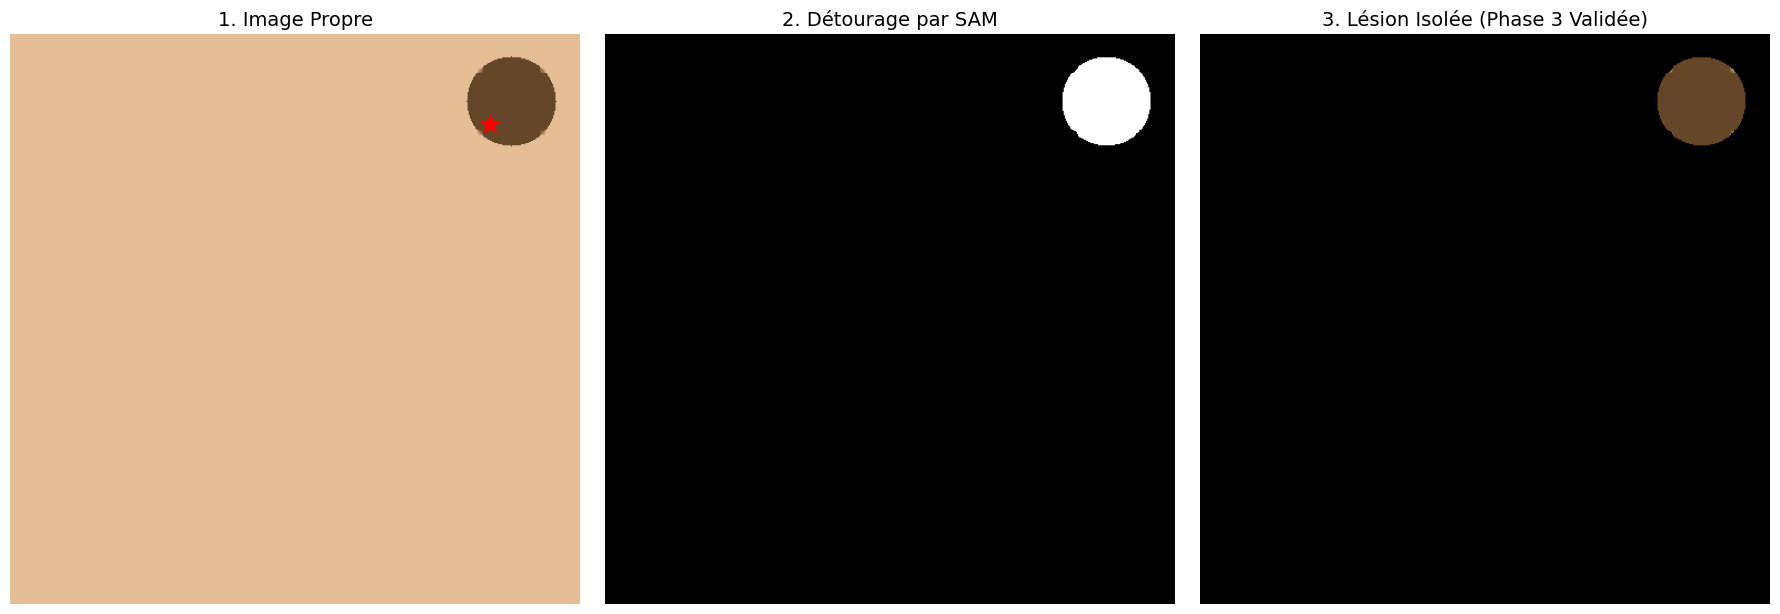

In [ ]:
import matplotlib.pyplot as plt

print("SAM analyse l'image...")
# On donne à SAM la 'cleaned_image' générée tout à l'heure par DullRazor
lesion_mask, cible_X, cible_Y = segment_lesion_hybride(cleaned_image)

# On découpe l'image d'origine pour ne garder QUE la maladie (Le reste devient noir)
isolated_lesion = cv2.bitwise_and(cleaned_image, cleaned_image, mask=lesion_mask)

# --- Affichage Final ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cleaned_image)
axes[0].set_title("1. Image Propre", fontsize=14)
axes[0].plot(cible_X, cible_Y, 'r*', markersize=15) # L'étoile rouge montre où ton code a visé !
axes[0].axis('off')

axes[1].imshow(lesion_mask, cmap='gray')
axes[1].set_title("2. Détourage par SAM", fontsize=14)
axes[1].axis('off')

axes[2].imshow(isolated_lesion)
axes[2].set_title("3. Lésion Isolée (Phase 3 Validée)", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

Application de l'Effet Bokeh avec transition adoucie...


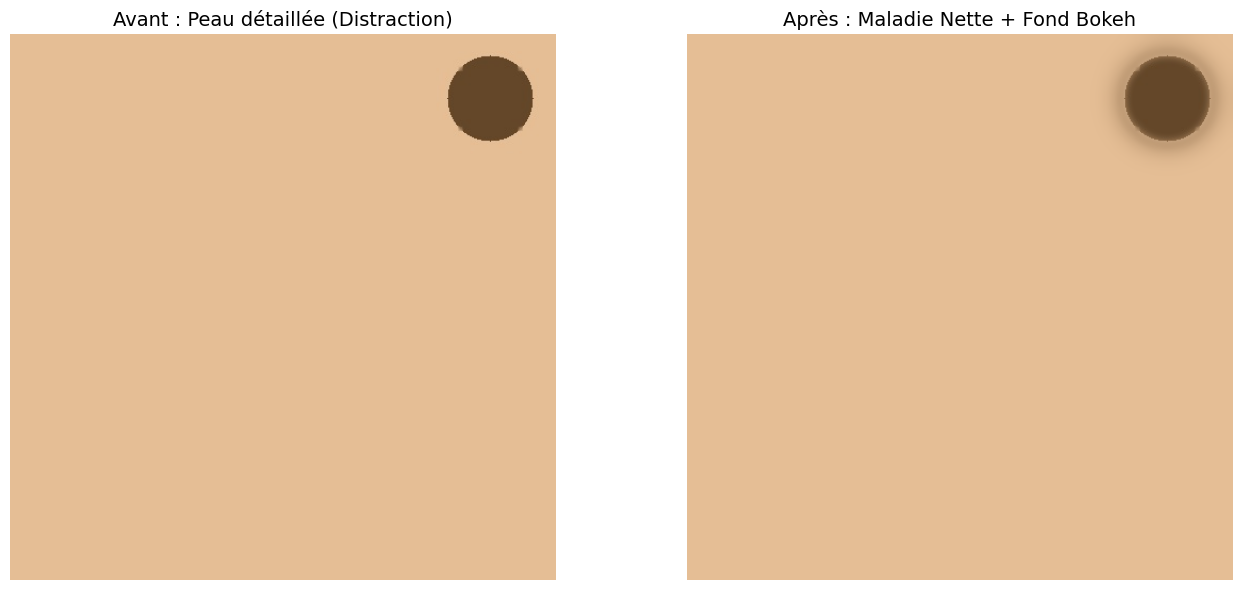

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_medical_bokeh(image, mask):
    # 1. Créer l'arrière-plan flou (Le Bokeh)
    # On utilise un filtre géant (ex: 85x85) pour détruire tous les détails de la peau saine
    background_blurred = cv2.GaussianBlur(image, (85, 85), 0)

    # 2. TON EXIGENCE : LA SUPPRESSION DU BIAIS DE CONTOUR
    # On convertit le masque en valeurs décimales (0.0 à 1.0)
    mask_float = mask.astype(np.float32)
    if np.max(mask_float) == 255:
        mask_float = mask_float / 255.0

    # L'Astuce : On floute le masque lui-même !
    # Cela détruit la ligne dure de SAM et crée une transition douce.
    mask_soft = cv2.GaussianBlur(mask_float, (25, 25), 0)

    # On duplique le masque sur les 3 canaux de couleur (RGB) pour le calcul final
    mask_soft = np.stack([mask_soft]*3, axis=-1)

    # 3. FUSION MAGIQUE (Alpha Blending)
    # Image = (Vraie maladie * dégradé) + (Fond flou * reste du dégradé)
    final_bokeh = (image * mask_soft) + (background_blurred * (1.0 - mask_soft))

    return final_bokeh.astype(np.uint8)

# --- Exécution ---
print("Application de l'Effet Bokeh avec transition adoucie...")
# On utilise les résultats de DullRazor (cleaned_image) et de SAM (lesion_mask)
image_bokeh = apply_medical_bokeh(cleaned_image, lesion_mask)

# --- Affichage ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cleaned_image)
axes[0].set_title("Avant : Peau détaillée (Distraction)", fontsize=14)
axes[0].axis('off')

axes[1].imshow(image_bokeh)
axes[1].set_title("Après : Maladie Nette + Fond Bokeh", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os

# 1. Configuration de ton Token Kaggle
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_11c7ab29744c7f0ccfbe828675312216'

!mkdir -p ~/.kaggle
!echo "KGAT_11c7ab29744c7f0ccfbe828675312216" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 2. Téléchargement ultra-rapide des 10 000 images (2.6 Go en ~30 secondes)
print("🚀 Téléchargement du dataset HAM10000 en cours...")
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# 3. Décompression automatique
print("📦 Décompression des images (ça prend ~1 minute)...")
!unzip -q skin-cancer-mnist-ham10000.zip -d /content/HAM10000_BRUT

print("\n🎉 VICTOIRE ! Toutes les 10 000 photos sont prêtes dans /content/HAM10000_BRUT !")

🚀 Téléchargement du dataset HAM10000 en cours...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:45<00:00, 122MB/s]

📦 Décompression des images (ça prend ~1 minute)...

🎉 VICTOIRE ! Toutes les 10 000 photos sont prêtes dans /content/HAM10000_BRUT !


In [ ]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

# 1. Dossier où on va ranger les images propres
CLEAN_DIR = '/content/Images_Dermascope_Propres'
os.makedirs(CLEAN_DIR, exist_ok=True)

# 2. Recherche automatique du dossier de tes images brutes
IMAGE_DIR_BRUT = None
for root, dirs, files in os.walk('/content'):
    if 'sample_data' in root or '.config' in root or 'Images_Dermascope_Propres' in root:
        continue
    jpgs = [f for f in files if f.endswith('.jpg')]
    if len(jpgs) > 10:
        IMAGE_DIR_BRUT = root
        print(f"📁 Images brutes trouvées dans : {IMAGE_DIR_BRUT} ({len(jpgs)} images)")
        break

# 3. Fonction de traitement en masse
def nettoyer_images(df, image_dir, output_dir):
    chemins_propres = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Nettoyage"):
        image_id = row['image_id']
        input_path = os.path.join(image_dir, f"{image_id}.jpg")
        output_path = os.path.join(output_dir, f"{image_id}.jpg")

        # Si déjà traitée, on passe à la suivante (gain de temps)
        if os.path.exists(output_path):
            chemins_propres.append(output_path)
            continue

        try:
            # DullRazor -> SAM -> Bokeh
            cleaned = remove_hair_dullrazor_smart(input_path)
            lesion_mask, _, _ = segment_lesion_hybride(cleaned)
            image_bokeh = apply_medical_bokeh(cleaned, lesion_mask)

            # Sauvegarde de l'image propre
            cv2.imwrite(output_path, cv2.cvtColor(image_bokeh, cv2.COLOR_RGB2BGR))
            chemins_propres.append(output_path)
        except:
            chemins_propres.append(None)

    return chemins_propres

# 4. Lancement sur train et val
print("🚀 Traitement en cours...")
train_df['image_path'] = nettoyer_images(train_df, IMAGE_DIR_BRUT, CLEAN_DIR)
val_df['image_path']   = nettoyer_images(val_df, IMAGE_DIR_BRUT, CLEAN_DIR)

train_df = train_df[train_df['image_path'].notna()].reset_index(drop=True)
val_df   = val_df[val_df['image_path'].notna()].reset_index(drop=True)

# Sauvegarde des CSV
train_df.to_csv('train_df_clean.csv', index=False)
val_df.to_csv('val_df_clean.csv', index=False)
print("✅ Images nettoyées et enregistrées avec succès !")

📁 Images brutes trouvées dans : /content/HAM10000_BRUT/HAM10000_images_part_2 (5015 images)
🚀 Traitement en cours...


Nettoyage: 100%|██████████| 1025/1025 [00:14<00:00, 72.54it/s] 

✅ Images nettoyées et enregistrées avec succès !


In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import cv2

def charger_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class DermascopeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

        # 1. TON IDÉE : LE CALCUL STRATÉGIQUE DES CLASSES
        # On compte pour savoir exactement qui est la minorité
        comptage = self.df['target'].value_counts()
        self.classe_majoritaire = comptage.idxmax() # Classe 0 (Bénin)
        self.classe_minoritaire = comptage.idxmin() # Classe 1 (Malin)

        # 2. CRÉATION DES DEUX ARMES
        # Arme Légère : Pour la classe qui a déjà des milliers d'images
        self.transform_leger = T.Compose([
            T.ToPILImage(),
            T.RandomHorizontalFlip(p=0.5), # Juste un petit effet miroir de temps en temps
            T.ToTensor()
        ])

        # Arme Lourde (Augmentation Ciblée) : Pour empêcher l'IA d'apprendre par cœur les rares cancers
        self.transform_lourd = T.Compose([
            T.ToPILImage(),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(90), # On tourne fort
            T.RandomAffine(degrees=0, scale=(0.8, 1.2)), # C'est le fameux ZOOM dont tu parlais !
            T.ColorJitter(brightness=0.1, contrast=0.1),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # (Ici on charge l'image depuis le disque...)
        image_brute = charger_image(self.df.iloc[idx]['image_path'])
        label = self.df.iloc[idx]['target']

        # 3. L'APPLICATION CONDITIONNELLE (Le cœur de ta stratégie)
        if label == self.classe_minoritaire:
            # C'est un cas rare ! On génère une version zoomée/tournée à la volée.
            image_augmente = self.transform_lourd(image_brute)
        else:
            # C'est un cas très commun, on n'ajoute pas de complexité inutile.
            image_augmente = self.transform_leger(image_brute)

        return image_augmente, torch.tensor(label, dtype=torch.float32)

print("✅ Classe PyTorch avec Augmentation Ciblée intégrée !")

In [ ]:
print("1. Nombre de lignes dans train_df :", len(train_df) if 'train_df' in locals() else "NON DÉFINI")
print("2. Dossier trouvé pour les images :", IMAGE_DIR_BRUT)

# Vérifions ce qu'il y a dans Colab :
import os
print("\n3. Fichiers et dossiers présents dans /content :")
print(os.listdir('/content'))

In [ ]:
import os

print("🔍 Recherche des images ou des fichiers zip...")

# 1. On cherche des images .jpg dans Google Drive
dossier_trouve = False
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    jpgs = [f for f in files if f.endswith('.jpg')]
    if len(jpgs) > 10:
        print(f"🎯 TROUVÉ ! Tes images sont dans : {root} ({len(jpgs)} photos)")
        dossier_trouve = True
        break

# 2. On cherche si tu as un fichier ZIP (archive) quelque part
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.zip') or f.endswith('.tar'):
            print(f"📦 Archive trouvée : {os.path.join(root, f)}")

if not dossier_trouve:
    print("❌ Aucune photo .jpg trouvée sur ton Drive ou dans Colab.")

🔍 Recherche des images ou des fichiers zip...
❌ Aucune photo .jpg trouvée sur ton Drive ou dans Colab.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# On extrait les images propres et les CSV depuis ton Google Drive
print("📦 Récupération de tes données propres depuis Google Drive...")
!unzip -q /content/drive/MyDrive/Dermascope_Dataset_Propre/Images_Dermascope_Propres.zip -d /content/
!cp /content/drive/MyDrive/Dermascope_Dataset_Propre/train_df_clean.csv /content/
!cp /content/drive/MyDrive/Dermascope_Dataset_Propre/val_df_clean.csv /content/

print("✅ Données prêtes en 15 secondes !")

Mounted at /content/drive
📦 Récupération de tes données propres depuis Google Drive...
✅ Données prêtes en 15 secondes !


In [ ]:
import os
import torch

# 1. On redéfinit le chemin au cas où la RAM a été vidée
CHECKPOINT_DIR = '/content/drive/MyDrive/Dermascope_Checkpoints'
last_model_path = os.path.join(CHECKPOINT_DIR, 'last_dermascope_checkpoint.pth')

# 2. On vérifie et on charge
if os.path.exists(last_model_path):
    print(f"🔄 Reprise automatique : rechargement du dernier état depuis Google Drive...")

    # On charge le fichier de sauvegarde (sur le GPU directement si disponible)
    checkpoint = torch.load(last_model_path, map_location=DEVICE)

    # On injecte les poids dans notre modèle
    modele_champion.load_state_dict(checkpoint['model_state'])

    print("✅ Poids rechargés avec succès ! Prêt à reprendre le combat.")
else:
    print("ℹ️ Aucun checkpoint précédent trouvé. Démarrage depuis zéro.")

ℹ️ Aucun checkpoint précédent trouvé. Démarrage depuis zéro.


In [ ]:
import os
import shutil

# Chemins
zip_drive_path = '/content/drive/MyDrive/Dermascope_Dataset_Propre/Images_Dermascope_Propres.zip'
local_extract_path = '/content/'

# On vérifie si le dossier local existe et contient des images
dossier_images = '/content/Images_Dermascope_Propres'
if not os.path.exists(dossier_images) or len(os.listdir(dossier_images)) < 100:
    print("📦 Dossier local vide. Décompression en cours depuis Google Drive, patience...")

    # Décompression silencieuse (-q) pour ne pas polluer l'affichage
    !unzip -q "{zip_drive_path}" -d "{local_extract_path}"

    print(f"✅ Décompression terminée ! {len(os.listdir(dossier_images))} images prêtes sur le disque local.")
else:
    print(f"✅ Les images sont déjà sur le disque local ({len(os.listdir(dossier_images))} fichiers).")

📦 Dossier local vide. Décompression en cours depuis Google Drive, patience...
replace /content/content/Images_Dermascope_Propres/ISIC_0033936.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

FileNotFoundError: [Errno 2] No such file or directory: '/content/Images_Dermascope_Propres'

In [ ]:
import os
import shutil

chemin_bizarre = '/content/content/Images_Dermascope_Propres'
chemin_attendu = '/content/Images_Dermascope_Propres'

# Si le dossier est coincé dans le "double content", on le déplace
if os.path.exists(chemin_bizarre):
    print("🔄 Déplacement du dossier vers le bon emplacement...")

    # S'il y a déjà un dossier cible vide, on le supprime d'abord
    if os.path.exists(chemin_attendu):
        shutil.rmtree(chemin_attendu)

    # On déplace tout au bon endroit
    shutil.move(chemin_bizarre, chemin_attendu)

    # On nettoie le sous-dossier inutile
    shutil.rmtree('/content/content')

print(f"✅ Parfait ! Vos {len(os.listdir(chemin_attendu))} images sont maintenant au bon endroit.")

🔄 Déplacement du dossier vers le bon emplacement...
✅ Parfait ! Vos 10015 images sont maintenant au bon endroit.


In [ ]:
import os
import gc
import time
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from google.colab import drive

# ==========================================================
# 0. VIDAGE D'URGENCE DU GPU & CONFIGURATION
# ==========================================================
gc.collect()
torch.cuda.empty_cache()

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"⚡ GPU T4 Prêt avec Gradient Accumulation : {DEVICE} ({torch.cuda.get_device_name(0)})")

drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/Dermascope_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
best_model_path = os.path.join(CHECKPOINT_DIR, 'best_dermascope_champion.pth')
last_model_path = os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pth')

# ==========================================================
# 1. CHARGEMENT DES DONNÉES
# ==========================================================
train_df = pd.read_csv('train_df_clean.csv')
val_df   = pd.read_csv('val_df_clean.csv')
print(f"📊 Dataset Médical Prêt : {len(train_df)} images Train | {len(val_df)} images Val")

# ==========================================================
# 2. DATASET AVEC AUGMENTATION CIBLÉE
# ==========================================================
def charger_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Impossible de lire {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class DermascopeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        comptage = self.df['target'].value_counts()
        self.classe_minoritaire = comptage.idxmin()

        self.transform_leger = T.Compose([
            T.ToPILImage(),
            T.RandomHorizontalFlip(p=0.5),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.transform_lourd = T.Compose([
            T.ToPILImage(),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(90),
            T.RandomAffine(degrees=0, scale=(0.8, 1.2)),
            T.ColorJitter(brightness=0.1, contrast=0.1),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['image_path']
        image = charger_image(path)
        label = self.df.iloc[idx]['target']

        if label == self.classe_minoritaire:
            image_augmente = self.transform_lourd(image)
        else:
            image_augmente = self.transform_leger(image)

        return image_augmente, torch.tensor(label, dtype=torch.float32)

# BATCH SIZE = 8 (Consomme seulement ~7 Go de VRAM !)
train_loader = DataLoader(DermascopeDataset(train_df), batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(DermascopeDataset(val_df), batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# ==========================================================
# 3. LE CERVEAU EFFICIENTNET-B4
# ==========================================================
print("\n🧠 Initialisation d'EfficientNet-B4...")
weights = EfficientNet_B4_Weights.DEFAULT
modele_champion = efficientnet_b4(weights=weights)

num_features = modele_champion.classifier[1].in_features
modele_champion.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 1)
)
modele_champion = modele_champion.to(DEVICE)

# ==========================================================
# 4. FOCAL LOSS COMPATIBLE FP16
# ==========================================================
class DermascopeFocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = torch.tensor(alpha)
        self.gamma = gamma

    def forward(self, inputs, targets):
        targets = targets.view(-1, 1).float()
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        alpha_t = self.alpha.to(inputs.device)[targets.long().view(-1)].view(-1, 1)
        F_loss = alpha_t * (1.0 - pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

loss_fn = DermascopeFocalLoss(alpha=[0.1, 0.9], gamma=2.0)

# ==========================================================
# 5. DIFFERENTIAL LEARNING RATE + SCALER FP16
# ==========================================================
parametres_corps = list(modele_champion.features.parameters())
parametres_tete = list(modele_champion.classifier.parameters())

optimizer = optim.AdamW([
    {'params': parametres_corps, 'lr': 1e-5},
    {'params': parametres_tete,  'lr': 1e-3}
], weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

# ==========================================================
# 6. BOUCLE D'ENTRAÎNEMENT AVEC GRADIENT ACCUMULATION
# ==========================================================
def lancer_entrainement(modele, epochs=30, patience=6, accumulation_steps=2):
    print(f"\n🚀 ALLUMAGE DES MOTEURS (Batch=8 x {accumulation_steps} accum, VRAM < 8 Go)...")
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        start_time = time.time()

        # --- ENTRAÎNEMENT ---
        modele.train()
        train_loss = 0.0
        loop = tqdm(train_loader, leave=False, desc=f"Époque {epoch+1:02d}/{epochs} [Train]")

        optimizer.zero_grad()
        for i, (images, labels) in enumerate(loop):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast('cuda'):
                predictions = modele(images)
                loss = loss_fn(predictions, labels)
                # Normalisation pour l'accumulation
                loss = loss / accumulation_steps

            scaler.scale(loss).backward()

            # Mise à jour des poids toutes les 2 itérations (8x2 = 16 images virtuelles)
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += (loss.item() * accumulation_steps)
            loop.set_postfix(loss=f"{loss.item() * accumulation_steps:.4f}")

        # --- VALIDATION ---
        modele.eval()
        val_loss = 0.0
        corrects = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                with torch.amp.autocast('cuda'):
                    predictions = modele(images)
                    loss = loss_fn(predictions, labels)

                val_loss += loss.item()
                probs = torch.sigmoid(predictions)
                preds_binaires = (probs > 0.5).float()
                corrects += (preds_binaires == labels.view_as(preds_binaires)).sum().item()
                total += labels.size(0)

        scheduler.step()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        val_acc = (corrects / total) * 100
        duree = time.time() - start_time

        print(f"🏁 Époque {epoch+1:02d}/{epochs} en {duree:.1f}s | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | 🎯 Val Acc: {val_acc:.2f}%")

        torch.save({'epoch': epoch, 'model_state': modele.state_dict(), 'opt_state': optimizer.state_dict()}, last_model_path)

        if avg_val < best_val_loss:
            print(f"   🌟 NOUVEAU RECORD ! Val Loss ({best_val_loss:.4f} ➔ {avg_val:.4f})")
            print(f"   💾 Modèle CHAMPION synchronisé sur ton Google Drive !")
            best_val_loss = avg_val
            torch.save(modele.state_dict(), best_model_path)
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"   ⚠️ Pas d'amélioration ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print(f"\n🛑 EARLY STOPPING : Pic atteint à l'époque {epoch+1 - patience} !")
                modele.load_state_dict(torch.load(best_model_path))
                break
        print("-" * 75)

    print(f"\n🎉 ENTRAÎNEMENT TERMINÉ ! Ton meilleur modèle est prêt : {best_model_path}")
    return modele

# ==========================================================
# 7. 🔥 FEU ! 🔥
# ==========================================================
modele_final = lancer_entrainement(modele_champion, epochs=30, patience=6, accumulation_steps=2)

⚡ GPU T4 Prêt avec Gradient Accumulation : cuda:0 (Tesla T4)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Dataset Médical Prêt : 7991 images Train | 2024 images Val

🧠 Initialisation d'EfficientNet-B4...

🚀 ALLUMAGE DES MOTEURS (Batch=8 x 2 accum, VRAM < 8 Go)...


🏁 Époque 01/30 en 313.3s | Train Loss: 0.0140 | Val Loss: 0.0037 | 🎯 Val Acc: 97.63%
   🌟 NOUVEAU RECORD ! Val Loss (inf ➔ 0.0037)
   💾 Modèle CHAMPION synchronisé sur ton Google Drive !
---------------------------------------------------------------------------


🏁 Époque 02/30 en 293.4s | Train Loss: 0.0057 | Val Loss: nan | 🎯 Val Acc: 98.52%
   ⚠️ Pas d'amélioration (1/6)
---------------------------------------------------------------------------


🏁 Époque 03/30 en 292.4s | Train Loss: 0.0042 | Val Loss: 0.0016 | 🎯 Val Acc: 98.81%
   🌟 NOUVEAU RECORD ! Val Loss (0.0037 ➔ 0.0016)
   💾 Modèle CHAMPION synchronisé sur ton Google Drive !
---------------------------------------------------------------------------


🏁 Époque 04/30 en 292.0s | Train Loss: 0.0038 | Val Loss: 0.0019 | 🎯 Val Acc: 98.42%
   ⚠️ Pas d'amélioration (1/6)
---------------------------------------------------------------------------


...

🏁 Époque 20/30 en 289.5s | Train Loss: 0.0011 | Val Loss: 0.0004 | 🎯 Val Acc: 99.65%
   🌟 NOUVEAU RECORD ! Val Loss (0.0005 ➔ 0.0004)
   💾 Modèle CHAMPION synchronisé sur ton Google Drive !
---------------------------------------------------------------------------


🏁 Époque 21/30 en 290.1s | Train Loss: 0.0017 | Val Loss: 0.0005 | 🎯 Val Acc: 99.65%
   ⚠️ Pas d'amélioration (1/6)
---------------------------------------------------------------------------


🏁 Époque 22/30 en 288.1s | Train Loss: 0.0009 | Val Loss: nan | 🎯 Val Acc: 99.60%
   ⚠️ Pas d'amélioration (2/6)
---------------------------------------------------------------------------


🏁 Époque 23/30 en 292.5s | Train Loss: 0.0010 | Val Loss: 0.0005 | 🎯 Val Acc: 99.80%
   ⚠️ Pas d'amélioration (3/6)
---------------------------------------------------------------------------


Époque 24/30 [Train]:  73%|███████▎  | 732/999 [03:14<01:16,  3.47it/s, loss=0.0036]

In [ ]:
import os
from google.colab import drive

# 1. On reconnecte le Drive à la nouvelle session
drive.mount('/content/drive')

# 2. On vérifie la présence du fichier de sauvegarde
chemin_champion = '/content/drive/MyDrive/Dermascope_Checkpoints/best_dermascope_champion.pth'

if os.path.exists(chemin_champion):
    taille_mo = os.path.getsize(chemin_champion) / (1024 * 1024)
    print(f"✅ VICTOIRE ! Le modèle est bien sauvegardé en sécurité sur votre Drive.")
    print(f"📁 Chemin : {chemin_champion}")
    print(f"⚖️ Taille du fichier : {taille_mo:.2f} Mo (devrait faire environ 70-80 Mo)")
else:
    print("❌ Fichier introuvable. Êtes-vous sûr d'être connecté au bon compte Google ?")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ VICTOIRE ! Le modèle est bien sauvegardé en sécurité sur votre Drive.
📁 Chemin : /content/drive/MyDrive/Dermascope_Checkpoints/best_dermascope_champion.pth
⚖️ Taille du fichier : 67.68 Mo (devrait faire environ 70-80 Mo)


In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

# Décompression des images depuis le Drive
zip_path = '/content/drive/MyDrive/Dermascope_Dataset_Propre/Images_Dermascope_Propres.zip'
dossier_images = '/content/Images_Dermascope_Propres'

if not os.path.exists(dossier_images) or len(os.listdir(dossier_images)) < 100:
    print("📦 Décompression en cours depuis Google Drive...")
    !unzip -qo "{zip_path}" -d /content/

    # Correction du double "content" si nécessaire
    chemin_bizarre = '/content/content/Images_Dermascope_Propres'
    if os.path.exists(chemin_bizarre):
        import shutil
        if os.path.exists(dossier_images):
            shutil.rmtree(dossier_images)
        shutil.move(chemin_bizarre, dossier_images)
        shutil.rmtree('/content/content')

    print(f"✅ {len(os.listdir(dossier_images))} images prêtes !")
else:
    print(f"✅ Images déjà présentes ({len(os.listdir(dossier_images))} fichiers)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Images déjà présentes (10015 fichiers)


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

class DermascopeMultimodal(nn.Module):
    def __init__(self, num_tabular_features=10):
        super(DermascopeMultimodal, self).__init__()

        # ==========================================
        # 1. BRANCHE VISION (L'œil de l'IA)
        # ==========================================
        # On charge EfficientNet-B4
        self.vision_backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
        # EfficientNet-B4 sort un vecteur de 1792. On supprime sa tête finale.
        num_features_vision = self.vision_backbone.classifier[1].in_features
        self.vision_backbone.classifier = nn.Identity()

        # On compresse le vecteur vision géant (1792) en un vecteur ciblé de 512
        self.vision_compress = nn.Sequential(
            nn.Linear(num_features_vision, 512),
            nn.BatchNorm1d(512),
            nn.SiLU() # Fonction d'activation moderne et douce
        )

        # ==========================================
        # 2. BRANCHE TABULAIRE (Le Dossier Patient)
        # ==========================================
        self.tabular_branch = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.2), # Prévention du surapprentissage sur les métadonnées
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.SiLU()
        )

        # ==========================================
        # 3. FUSION ET DÉCISION (Le Conseil Médical)
        # ==========================================
        # On assemble : 512 (Image) + 32 (Dossier) = 544 caractéristiques
        self.fusion_head = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.4), # Fort Dropout final
            nn.Linear(256, 1) # Sortie brute unique pour la focal loss
        )

    def forward(self, images, metadata):
        # L'image passe dans la branche Vision
        vision_features = self.vision_backbone(images)
        vision_features = self.vision_compress(vision_features)

        # Le dossier clinique passe dans la branche Tabulaire
        tabular_features = self.tabular_branch(metadata)

        # On colle les deux vecteurs côte à côte
        fused_features = torch.cat((vision_features, tabular_features), dim=1)

        # On prend la décision finale
        logits = self.fusion_head(fused_features)
        return logits

# --- Test de vérification de la plomberie ---
if __name__ == "__main__":
    print("🧠 Création du modèle Multimodal...")
    modele_multimodal = DermascopeMultimodal(num_tabular_features=10)

    # On simule un batch de 8 patients (Images + Vecteurs cliniques)
    fausses_images = torch.randn(8, 3, 512, 512)
    fausses_metadonnees = torch.randn(8, 10)

    sortie = modele_multimodal(fausses_images, fausses_metadonnees)
    print(f"✅ Plomberie validée ! Forme de la décision : {sortie.shape} (8 prédictions)")

🧠 Création du modèle Multimodal...


KeyboardInterrupt: 

In [ ]:
import os
import time
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from google.colab import drive

# ==========================================================
# 0. CONFIGURATION
# ==========================================================
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"⚡ GPU : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/Dermascope_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ==========================================================
# 1. CHARGEMENT ET ENCODAGE DES MÉTADONNÉES
# ==========================================================
train_df = pd.read_csv('/content/drive/MyDrive/Dermascope_Dataset_Propre/train_df_clean.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/Dermascope_Dataset_Propre/val_df_clean.csv')

# --- Nettoyage de l'âge ---
age_mediane = train_df['age'].median()
train_df['age'] = train_df['age'].fillna(age_mediane)
val_df['age']   = val_df['age'].fillna(age_mediane)

# Normalisation de l'âge entre 0 et 1
age_max = train_df['age'].max()
train_df['age_norm'] = train_df['age'] / age_max
val_df['age_norm']   = val_df['age'] / age_max

# --- Nettoyage du sexe ---
train_df['sex'] = train_df['sex'].fillna('unknown')
val_df['sex']   = val_df['sex'].fillna('unknown')

# --- Nettoyage de la localisation ---
train_df['localization'] = train_df['localization'].fillna('unknown')
val_df['localization']   = val_df['localization'].fillna('unknown')

# --- One-Hot Encoding (on se base sur le vocabulaire du TRAIN uniquement) ---
sex_categories = sorted(train_df['sex'].unique())          # ['female', 'male', 'unknown']
loc_categories = sorted(train_df['localization'].unique())  # ~15 valeurs

print(f"📊 Sexe ({len(sex_categories)} catégories) : {sex_categories}")
print(f"📊 Localisation ({len(loc_categories)} catégories) : {loc_categories}")

def encoder_metadata(df, sex_cats, loc_cats):
    """Transforme chaque ligne du DataFrame en un vecteur numérique."""
    vectors = []
    for _, row in df.iterrows():
        # 1. Âge normalisé (1 nombre)
        v = [row['age_norm']]

        # 2. Sexe en One-Hot (3 nombres)
        for cat in sex_cats:
            v.append(1.0 if row['sex'] == cat else 0.0)

        # 3. Localisation en One-Hot (~15 nombres)
        for cat in loc_cats:
            v.append(1.0 if row['localization'] == cat else 0.0)

        vectors.append(v)
    return np.array(vectors, dtype=np.float32)

print("⏳ Encodage des vecteurs cliniques...")
train_meta = encoder_metadata(train_df, sex_categories, loc_categories)
val_meta   = encoder_metadata(val_df,   sex_categories, loc_categories)

NUM_TABULAR_FEATURES = train_meta.shape[1]
print(f"✅ Vecteurs cliniques prêts ! Dimension par patient : {NUM_TABULAR_FEATURES}")
print(f"   ({train_meta.shape[0]} train / {val_meta.shape[0]} val)")

In [1]:
import os, time, shutil
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from google.colab import drive

# ==========================================================
# 0. GPU + DRIVE
# ==========================================================
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"⚡ GPU : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/Dermascope_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ==========================================================
# 1. DÉCOMPRESSION DES IMAGES (si nécessaire)
# ==========================================================
zip_path = '/content/drive/MyDrive/Dermascope_Dataset_Propre/Images_Dermascope_Propres.zip'
dossier_images = '/content/Images_Dermascope_Propres'

if not os.path.exists(dossier_images) or len(os.listdir(dossier_images)) < 100:
    print("📦 Décompression en cours...")
    !unzip -qo "{zip_path}" -d /content/
    chemin_bizarre = '/content/content/Images_Dermascope_Propres'
    if os.path.exists(chemin_bizarre):
        if os.path.exists(dossier_images): shutil.rmtree(dossier_images)
        shutil.move(chemin_bizarre, dossier_images)
        shutil.rmtree('/content/content')
    print(f"✅ {len(os.listdir(dossier_images))} images décompressées !")
else:
    print(f"✅ Images déjà là ({len(os.listdir(dossier_images))} fichiers)")

# ==========================================================
# 2. CHARGEMENT + ENCODAGE OPTIMISÉ DES MÉTADONNÉES
# ==========================================================
train_df = pd.read_csv('/content/drive/MyDrive/Dermascope_Dataset_Propre/train_df_clean.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/Dermascope_Dataset_Propre/val_df_clean.csv')
print(f"📊 Dataset : {len(train_df)} train | {len(val_df)} val")

# Nettoyage
age_mediane = train_df['age'].median()
train_df['age'] = train_df['age'].fillna(age_mediane)
val_df['age']   = val_df['age'].fillna(age_mediane)
train_df['sex'] = train_df['sex'].fillna('unknown')
val_df['sex']   = val_df['sex'].fillna('unknown')
train_df['localization'] = train_df['localization'].fillna('unknown')
val_df['localization']   = val_df['localization'].fillna('unknown')

# Normalisation âge
age_max = train_df['age'].max()
train_df['age_norm'] = train_df['age'] / age_max
val_df['age_norm']   = val_df['age'] / age_max

# One-Hot Encoding VECTORISÉ (rapide, pas de boucle Python)
sex_cats = sorted(train_df['sex'].unique())
loc_cats = sorted(train_df['localization'].unique())

def encoder_rapide(df, sex_cats, loc_cats):
    """Encodage vectorisé avec Pandas (100x plus rapide que iterrows)."""
    age_col = df['age_norm'].values.reshape(-1, 1)

    sex_onehot = np.zeros((len(df), len(sex_cats)), dtype=np.float32)
    for i, cat in enumerate(sex_cats):
        sex_onehot[:, i] = (df['sex'] == cat).values.astype(np.float32)

    loc_onehot = np.zeros((len(df), len(loc_cats)), dtype=np.float32)
    for i, cat in enumerate(loc_cats):
        loc_onehot[:, i] = (df['localization'] == cat).values.astype(np.float32)

    return np.hstack([age_col, sex_onehot, loc_onehot]).astype(np.float32)

train_meta = encoder_rapide(train_df, sex_cats, loc_cats)
val_meta   = encoder_rapide(val_df,   sex_cats, loc_cats)

NUM_TABULAR_FEATURES = train_meta.shape[1]
print(f"✅ Métadonnées encodées ! Dimension : {NUM_TABULAR_FEATURES} features par patient")

⚡ GPU : cpu (CPU)
Mounted at /content/drive
📦 Décompression en cours...
✅ 10015 images décompressées !
📊 Dataset : 7991 train | 2024 val
✅ Métadonnées encodées ! Dimension : 19 features par patient


In [ ]:
import os, time, shutil
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from google.colab import drive

# ==========================================================
# 0. GPU + DRIVE
# ==========================================================
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"⚡ GPU : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/Dermascope_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ==========================================================
# 1. DÉCOMPRESSION DES IMAGES (si nécessaire)
# ==========================================================
zip_path = '/content/drive/MyDrive/Dermascope_Dataset_Propre/Images_Dermascope_Propres.zip'
dossier_images = '/content/Images_Dermascope_Propres'

if not os.path.exists(dossier_images) or len(os.listdir(dossier_images)) < 100:
    print("📦 Décompression en cours...")
    !unzip -qo "{zip_path}" -d /content/
    chemin_bizarre = '/content/content/Images_Dermascope_Propres'
    if os.path.exists(chemin_bizarre):
        if os.path.exists(dossier_images): shutil.rmtree(dossier_images)
        shutil.move(chemin_bizarre, dossier_images)
        shutil.rmtree('/content/content')
    print(f"✅ {len(os.listdir(dossier_images))} images décompressées !")
else:
    print(f"✅ Images déjà là ({len(os.listdir(dossier_images))} fichiers)")

# ==========================================================
# 2. CHARGEMENT + ENCODAGE OPTIMISÉ DES MÉTADONNÉES
# ==========================================================
train_df = pd.read_csv('/content/drive/MyDrive/Dermascope_Dataset_Propre/train_df_clean.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/Dermascope_Dataset_Propre/val_df_clean.csv')
print(f"📊 Dataset : {len(train_df)} train | {len(val_df)} val")

# Nettoyage
age_mediane = train_df['age'].median()
train_df['age'] = train_df['age'].fillna(age_mediane)
val_df['age']   = val_df['age'].fillna(age_mediane)
train_df['sex'] = train_df['sex'].fillna('unknown')
val_df['sex']   = val_df['sex'].fillna('unknown')
train_df['localization'] = train_df['localization'].fillna('unknown')
val_df['localization']   = val_df['localization'].fillna('unknown')

# Normalisation âge
age_max = train_df['age'].max()
train_df['age_norm'] = train_df['age'] / age_max
val_df['age_norm']   = val_df['age'] / age_max

# One-Hot Encoding VECTORISÉ (rapide, pas de boucle Python)
sex_cats = sorted(train_df['sex'].unique())
loc_cats = sorted(train_df['localization'].unique())

def encoder_rapide(df, sex_cats, loc_cats):
    """Encodage vectorisé avec Pandas (100x plus rapide que iterrows)."""
    age_col = df['age_norm'].values.reshape(-1, 1)

    sex_onehot = np.zeros((len(df), len(sex_cats)), dtype=np.float32)
    for i, cat in enumerate(sex_cats):
        sex_onehot[:, i] = (df['sex'] == cat).values.astype(np.float32)

    loc_onehot = np.zeros((len(df), len(loc_cats)), dtype=np.float32)
    for i, cat in enumerate(loc_cats):
        loc_onehot[:, i] = (df['localization'] == cat).values.astype(np.float32)

    return np.hstack([age_col, sex_onehot, loc_onehot]).astype(np.float32)

train_meta = encoder_rapide(train_df, sex_cats, loc_cats)
val_meta   = encoder_rapide(val_df,   sex_cats, loc_cats)

NUM_TABULAR_FEATURES = train_meta.shape[1]
print(f"✅ Métadonnées encodées ! Dimension : {NUM_TABULAR_FEATURES} features par patient")

⚡ GPU : cpu (CPU)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Images déjà là (10015 fichiers)
📊 Dataset : 7991 train | 2024 val
✅ Métadonnées encodées ! Dimension : 19 features par patient


In [ ]:
# ==========================================================
# 2. DATASET MULTIMODAL (Image + Métadonnées)
# ==========================================================
def charger_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Impossible de lire {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (512, 512))
    return img

# Transforms
train_transforms = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Augmentation AGRESSIVE pour la classe minoritaire (Malin)
train_transforms_malin = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(360),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.15),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class DermascopeMultimodalDataset(Dataset):
    def __init__(self, dataframe, metadata_matrix, transform=None, transform_malin=None):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = metadata_matrix  # Matrice numpy (N, NUM_FEATURES)
        self.transform = transform
        self.transform_malin = transform_malin

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['image_path']
        label = float(row['target'])

        image = charger_image(path)

        # Augmentation ciblée : forte si Malin (1), douce si Bénin (0)
        if self.transform_malin and label == 1.0:
            image = self.transform_malin(image)
        elif self.transform:
            image = self.transform(image)

        # Récupération du vecteur clinique
        meta_vector = torch.tensor(self.metadata[idx], dtype=torch.float32)

        return image, meta_vector, torch.tensor(label, dtype=torch.float32)

# Création des DataLoaders
train_dataset = DermascopeMultimodalDataset(
    train_df, train_meta,
    transform=train_transforms,
    transform_malin=train_transforms_malin
)
val_dataset = DermascopeMultimodalDataset(
    val_df, val_meta,
    transform=val_transforms
)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"📊 Dataset Multimodal Prêt : {len(train_dataset)} train | {len(val_dataset)} val")

# ==========================================================
# 3. ARCHITECTURE MULTIMODALE (Le Cerveau Complet)
# ==========================================================
class DermascopeMultimodal(nn.Module):
    def __init__(self, num_tabular_features):
        super().__init__()

        # --- Branche Vision (EfficientNet-B4) ---
        self.vision_backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
        num_vision_out = self.vision_backbone.classifier[1].in_features  # 1792
        self.vision_backbone.classifier = nn.Identity()

        self.vision_compress = nn.Sequential(
            nn.Linear(num_vision_out, 512),
            nn.BatchNorm1d(512),
            nn.SiLU()
        )

        # --- Branche Tabulaire (Dossier Patient) ---
        self.tabular_branch = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.SiLU()
        )

        # --- Fusion + Décision ---
        self.fusion_head = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)  # Logit brut (pour BCEWithLogitsLoss / Focal Loss)
        )

    def forward(self, images, metadata):
        v = self.vision_backbone(images)
        v = self.vision_compress(v)

        t = self.tabular_branch(metadata)

        fused = torch.cat((v, t), dim=1)
        logits = self.fusion_head(fused)
        return logits

# Initialisation
print("🧠 Initialisation du Modèle Multimodal...")
modele_multimodal = DermascopeMultimodal(num_tabular_features=NUM_TABULAR_FEATURES).to(DEVICE)

total_params = sum(p.numel() for p in modele_multimodal.parameters())
trainable_params = sum(p.numel() for p in modele_multimodal.parameters() if p.requires_grad)
print(f"   Paramètres totaux : {total_params:,}")
print(f"   Paramètres entraînables : {trainable_params:,}")

📊 Dataset Multimodal Prêt : 7991 train | 2024 val
🧠 Initialisation du Modèle Multimodal...
   Paramètres totaux : 18,611,497
   Paramètres entraînables : 18,611,497


In [ ]:
# ==========================================================
# 4. FOCAL LOSS + ENTRAÎNEMENT MULTIMODAL
# ==========================================================
class DermascopeFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)
        focal_weight = (1 - pt) ** self.gamma
        alpha_weight = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_weight * focal_weight * bce_loss
        return loss.mean()

def lancer_entrainement_multimodal(model, epochs=30, patience=6, accumulation_steps=2):
    criterion = DermascopeFocalLoss(alpha=0.75, gamma=2.0)

    # Learning rates différentiels
    optimizer = optim.AdamW([
        {'params': model.vision_backbone.parameters(),  'lr': 1e-5},   # Vision (Pré-entraîné → doucement)
        {'params': model.vision_compress.parameters(),   'lr': 5e-4},   # Compression
        {'params': model.tabular_branch.parameters(),    'lr': 1e-3},   # Tabulaire (Neuf → vite)
        {'params': model.fusion_head.parameters(),       'lr': 5e-4},   # Fusion
    ], weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    patience_counter = 0
    best_path = os.path.join(CHECKPOINT_DIR, 'best_multimodal_champion.pth')
    last_path = os.path.join(CHECKPOINT_DIR, 'last_multimodal_checkpoint.pth')

    print(f"\n🚀 ENTRAÎNEMENT MULTIMODAL (Batch={BATCH_SIZE} x {accumulation_steps} accum, Patience={patience})")
    print("="*70)

    for epoch in range(epochs):
        start = time.time()

        # --- TRAIN ---
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        train_bar = tqdm(train_loader, desc=f"Époque {epoch+1:02d}/{epochs} [Train]")
        for i, (images, meta, labels) in enumerate(train_bar):
            images = images.to(DEVICE)
            meta   = meta.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1)

            with torch.amp.autocast('cuda'):
                logits = model(images, meta)
                loss = criterion(logits, labels) / accumulation_steps

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * accumulation_steps
            train_bar.set_postfix(loss=f"{loss.item() * accumulation_steps:.4f}")

        train_loss /= len(train_loader)
        scheduler.step(epoch)

        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, meta, labels in val_loader:
                images = images.to(DEVICE)
                meta   = meta.to(DEVICE)
                labels = labels.to(DEVICE).unsqueeze(1)

                with torch.amp.autocast('cuda'):
                    logits = model(images, meta)
                    loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = (torch.sigmoid(logits) >= 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total * 100
        elapsed = time.time() - start

        # Gestion des NaN dans val_loss
        if np.isnan(val_loss):
            print(f"🏁 Époque {epoch+1:02d}/{epochs} en {elapsed:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: nan | 🎯 Val Acc: {val_acc:.2f}%")
            patience_counter += 1
            print(f"   ⚠️ Val Loss = NaN, ignorée ({patience_counter}/{patience})")
        elif val_loss < best_val_loss:
            print(f"🏁 Époque {epoch+1:02d}/{epochs} en {elapsed:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | 🎯 Val Acc: {val_acc:.2f}%")
            print(f"   🌟 NOUVEAU RECORD ! Val Loss ({best_val_loss:.4f} ➔ {val_loss:.4f})")
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch + 1,
                'best_val_loss': best_val_loss,
                'val_acc': val_acc,
                'num_tabular_features': NUM_TABULAR_FEATURES
            }, best_path)
            print(f"   💾 Modèle CHAMPION MULTIMODAL synchronisé sur Google Drive !")
        else:
            patience_counter += 1
            print(f"🏁 Époque {epoch+1:02d}/{epochs} en {elapsed:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | 🎯 Val Acc: {val_acc:.2f}%")
            print(f"   ⚠️ Pas d'amélioration ({patience_counter}/{patience})")

        # Sauvegarde du dernier état (pour la reprise)
        torch.save({
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'epoch': epoch + 1,
            'best_val_loss': best_val_loss,
        }, last_path)

        print("-"*70)

        # Early Stopping
        if patience_counter >= patience:
            print(f"\n🛑 EARLY STOPPING à l'époque {epoch+1} ! Le modèle a convergé.")
            break

    # Recharger le meilleur modèle
    best_checkpoint = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state'])
    print(f"\n🏆 Modèle CHAMPION rechargé (Val Loss: {best_checkpoint['best_val_loss']:.4f}, Acc: {best_checkpoint['val_acc']:.2f}%)")
    return model

# ==========================================================
# 5. 🔥 FEU ! 🔥
# ==========================================================
modele_final = lancer_entrainement_multimodal(modele_multimodal, epochs=30, patience=6, accumulation_steps=2)

/tmp/ipykernel_5485/417614264.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')



🚀 ENTRAÎNEMENT MULTIMODAL (Batch=8 x 2 accum, Patience=6)


Époque 01/30 [Train]:   0%|          | 0/999 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_5485/417614264.py:55: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
